# Exercise 4 — Global vs. Local Explanations

**PCS956 • Module C • Week 1**

## Research question

**How do global and local explanations answer different questions about the same fitted model?**

In this exercise, we will:

- use the same Titanic prediction task as in the previous exercises;
- fit a Random Forest;
- use SHAP to explain the fitted model;
- construct a global explanation by aggregating local SHAP values;
- inspect local explanations for individual passengers;
- compare explanations for two contrasting cases;
- examine how local explanations can vary across observations; and
- discuss why one local explanation should not be generalised to the whole model.

The key distinction is:

- **global explanation** — summarises broader model behaviour across many observations;
- **local explanation** — focuses on one particular prediction.


## 1. Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier


## 2. Prepare the Titanic data

We use the same variables and preprocessing strategy as in Exercises 1–3, so the exploratory dataset visualisations are not repeated here.

The target is:

- `survived = 0` — did not survive;
- `survived = 1` — survived.

Categorical variables are one-hot encoded and all categories are retained.

Therefore:

- `sex` becomes `sex_female` and `sex_male`;
- `embarked` becomes `embarked_C`, `embarked_Q`, and `embarked_S`.

Because `sex_female` and `sex_male` are complementary encodings of the same original binary variable, a model may distribute attribution across either representation.


In [ ]:
RANDOM_STATE = 42

# Load the Titanic dataset.
titanic = sns.load_dataset("titanic")

FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

# Split before fitting preprocessing.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numerical preprocessing.
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    verbose_feature_names_out=False
)

# Learn preprocessing from the training set only.
X_train = preprocessor.fit_transform(X_train_raw)

# Apply the fitted preprocessing to the test set.
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:")
print(list(feature_names))


Training observations: 712
Test observations: 179
Transformed features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 3. Fit the Random Forest

We use one fitted model throughout this exercise.

Keeping the model fixed allows us to focus on the difference between **global** and **local** explanations rather than differences between model architectures.


In [ ]:
forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest_model.fit(
    X_train_df,
    y_train
)

train_pred = forest_model.predict(
    X_train_df
)

test_pred = forest_model.predict(
    X_test_df
)

print(
    "Training accuracy:",
    round(
        accuracy_score(
            y_train,
            train_pred
        ),
        3
    )
)

print(
    "Test accuracy:",
    round(
        accuracy_score(
            y_test,
            test_pred
        ),
        3
    )
)

print(
    "Test balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            test_pred
        ),
        3
    )
)


Training accuracy: 0.983
Test accuracy: 0.821
Test balanced accuracy: 0.798


### Why report performance?

Explanations describe the behaviour of a fitted model.

Before interpreting explanations, we should know how that model performs on held-out data.

A convincing explanation of a poorly performing model would still be an explanation of a poor model.


## 4. Compute SHAP values

We apply SHAP after the Random Forest has been trained.

For this tree-based model, we use `TreeExplainer`.

We focus on the output for:

> **class 1 — survived**

For each observation, SHAP assigns an attribution value to each input feature.

These SHAP values describe how the features contribute to the fitted model output relative to the explainer's reference value.

At this stage, the SHAP values are **local** because they are computed for individual observations.

In the next sections, we will use these local attributions in two ways:

- aggregate them across many observations to obtain a **global summary**;
- inspect them for one observation to obtain a **local explanation**.

## Global vs. local: the same model, different questions

We explain the **same fitted Random Forest** from two different perspectives.

### Global explanation

> **How does the model behave across many observations?**

A global explanation summarises patterns across a collection of observations.

### Local explanation

> **How does the model behave for one particular observation?**

A local explanation focuses on a specific prediction.

The main difference is therefore one of **scope**:

**Global → many observations**

**Local → one observation**

In [ ]:
explainer = shap.TreeExplainer(
    forest_model
)

shap_values = explainer(
    X_test_df
)

# Extract class-1 SHAP values in a version-robust way.
if shap_values.values.ndim == 3:
    survived_shap = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    )
else:
    survived_shap = shap_values

print(
    "Class-1 SHAP matrix shape:",
    survived_shap.values.shape
)


Class-1 SHAP matrix shape: (179, 10)


## 5. Global explanation

A global explanation summarises model behaviour across many observations.

One common approach is to aggregate the absolute SHAP values across the test set.

For each transformed feature, we compute:

> **mean absolute SHAP value**

This measures how large that feature's attribution tends to be across the explained observations.


In [ ]:
mean_abs_shap = pd.Series(
    np.abs(
        survived_shap.values
    ).mean(axis=0),
    index=feature_names
).sort_values(
    ascending=False
)

global_table = (
    mean_abs_shap
    .rename(
        "mean_absolute_SHAP"
    )
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

display(
    global_table
)


,feature,mean_absolute_SHAP
0,sex_male,0.118387
1,sex_female,0.103019
2,pclass,0.081819
3,fare,0.068870
4,age,0.052159
5,sibsp,0.024860
6,embarked_S,0.021304
7,embarked_C,0.014872
8,parch,0.012370
9,embarked_Q,0.006293


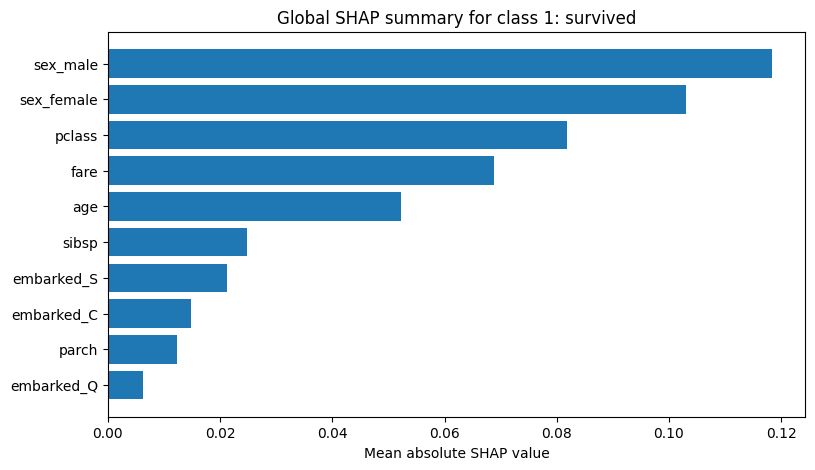

In [ ]:
plot_table = (
    global_table
    .sort_values(
        "mean_absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_table["feature"],
    plot_table["mean_absolute_SHAP"]
)

plt.xlabel(
    "Mean absolute SHAP value"
)

plt.title(
    "Global SHAP summary for class 1: survived"
)

plt.show()


### Interpreting the global summary

A feature with a larger mean absolute SHAP value tended to receive larger-magnitude attributions across the explained test observations.

This tells us about **overall attribution magnitude**.

It does not tell us:

- whether the attribution is usually positive or negative;
- whether every passenger receives a similar explanation;
- whether the feature causally affects survival.


## 6. SHAP beeswarm — global distribution of local attributions

The bar chart above summarises attribution magnitude.

A beeswarm plot retains more information because it shows the distribution of local SHAP values across many observations.

Each point corresponds to one observation–feature attribution.


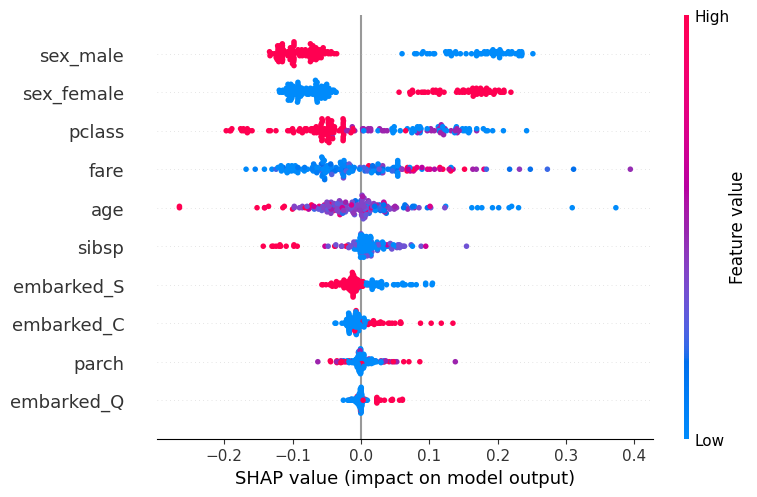

In [ ]:
shap.plots.beeswarm(
    survived_shap,
    max_display=10
)


### How to read the beeswarm plot

For each feature:

- points to the right have positive SHAP values for the class-1 output;
- points to the left have negative SHAP values;
- horizontal spread shows how attribution varies across observations;
- point colour represents the feature value used by SHAP's visualisation.

The beeswarm is global because it summarises many local explanations together.


## 7. Local explanation for one passenger

We now move from the behaviour of the model across many observations to one individual prediction.

A local explanation answers a question such as:

> **Which transformed features received important attributions for this particular prediction?**


In [ ]:
# Prefer a misclassified case if one exists.
misclassified_positions = np.flatnonzero(
    test_pred != y_test.to_numpy()
)

if len(misclassified_positions) > 0:
    sample_position = int(
        misclassified_positions[0]
    )
    selection_reason = "misclassified test case"
else:
    sample_position = 0
    selection_reason = "first test case"

raw_sample = X_test_raw.iloc[
    [sample_position]
]

true_class = int(
    y_test.iloc[
        sample_position
    ]
)

predicted_class = int(
    forest_model.predict(
        X_test_df.iloc[
            [sample_position]
        ]
    )[0]
)

predicted_probability = float(
    forest_model.predict_proba(
        X_test_df.iloc[
            [sample_position]
        ]
    )[0, 1]
)

print(
    "Selected:",
    selection_reason
)

display(
    raw_sample
)

print(
    "Observed outcome:",
    "survived"
    if true_class == 1
    else "did not survive"
)

print(
    "Predicted class:",
    "survived"
    if predicted_class == 1
    else "did not survive"
)

print(
    "Predicted probability of survival:",
    round(
        predicted_probability,
        3
    )
)


Selected: misclassified test case


,pclass,sex,age,sibsp,parch,fare,embarked
553,3,male,22.0,0,0,7.225,C


Observed outcome: survived
Predicted class: did not survive
Predicted probability of survival: 0.06


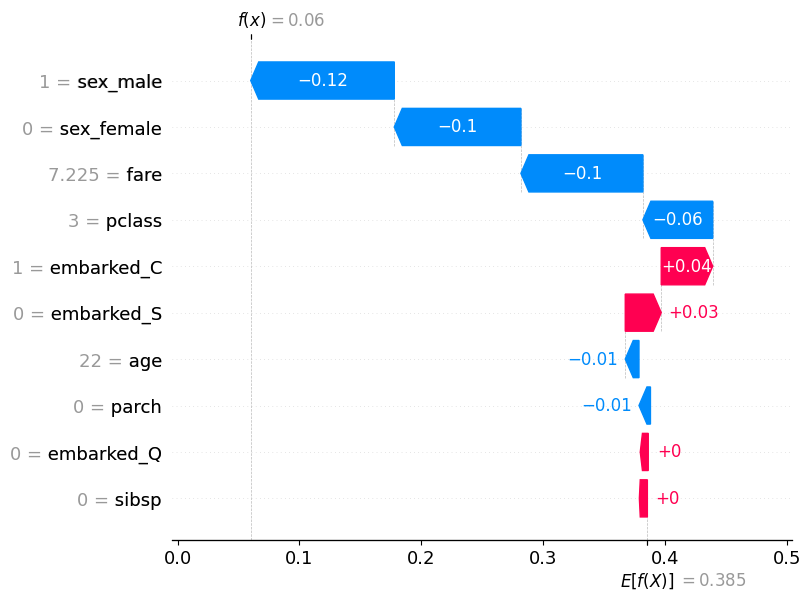

In [ ]:
shap.plots.waterfall(
    survived_shap[
        sample_position
    ],
    max_display=10
)


### Interpreting the local explanation

The waterfall plot starts from the SHAP reference value and adds the attributions for this one observation.

For the class-1 output:

- positive SHAP values move the explained output upward relative to the reference;
- negative SHAP values move it downward.

This explanation applies to this selected observation.

It should not automatically be treated as a description of how the model behaves for all passengers.


## 8. Compare two contrasting local explanations

Two passengers can receive the same predicted class but have different attribution patterns.

Conversely, two passengers can receive different predicted classes even when some features contribute in similar directions.

We therefore compare two observations with contrasting predicted survival probabilities.


In [ ]:
# Predicted probability of survival for every test observation.
survival_probabilities = forest_model.predict_proba(
    X_test_df
)[:, 1]

# Observation with the lowest and highest predicted survival probability.
low_position = int(
    np.argmin(
        survival_probabilities
    )
)

high_position = int(
    np.argmax(
        survival_probabilities
    )
)

comparison_table = pd.DataFrame({
    "case": [
        "Lowest predicted survival probability",
        "Highest predicted survival probability"
    ],
    "test_position": [
        low_position,
        high_position
    ],
    "predicted_survival_probability": [
        survival_probabilities[
            low_position
        ],
        survival_probabilities[
            high_position
        ]
    ],
    "observed_outcome": [
        int(
            y_test.iloc[
                low_position
            ]
        ),
        int(
            y_test.iloc[
                high_position
            ]
        )
    ]
})

display(
    comparison_table
)

print(
    "Passenger with lowest predicted survival probability:"
)

display(
    X_test_raw.iloc[
        [low_position]
    ]
)

print(
    "Passenger with highest predicted survival probability:"
)

display(
    X_test_raw.iloc[
        [high_position]
    ]
)


,case,test_position,predicted_survival_probability,observed_outcome
0,Lowest predicted survival probability,17,0.0,0
1,Highest predicted survival probability,25,1.0,1


Passenger with lowest predicted survival probability:


,pclass,sex,age,sibsp,parch,fare,embarked
511,3,male,NaN,0,0,8.05,S


Passenger with highest predicted survival probability:


,pclass,sex,age,sibsp,parch,fare,embarked
369,1,female,24.0,0,0,69.3,C


### Local explanation — low predicted survival probability


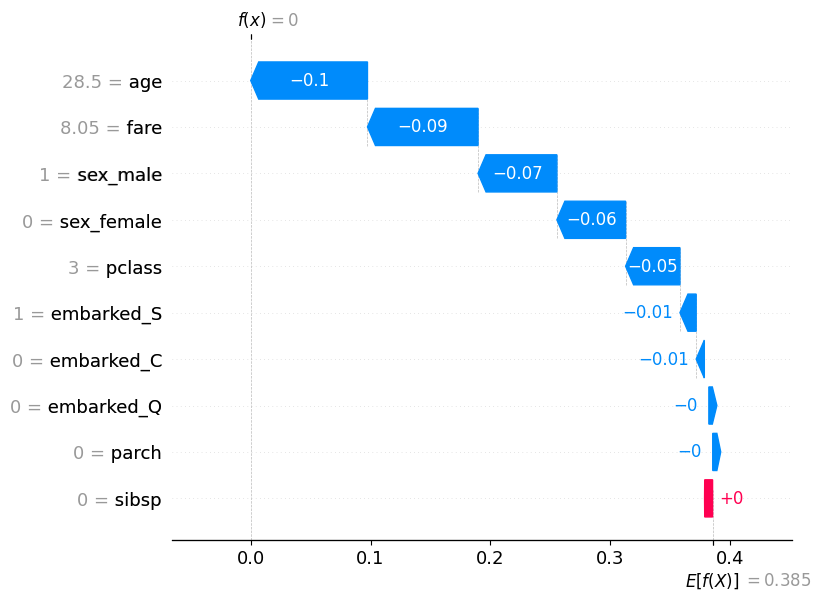

In [ ]:
shap.plots.waterfall(
    survived_shap[
        low_position
    ],
    max_display=10
)


### Local explanation — high predicted survival probability


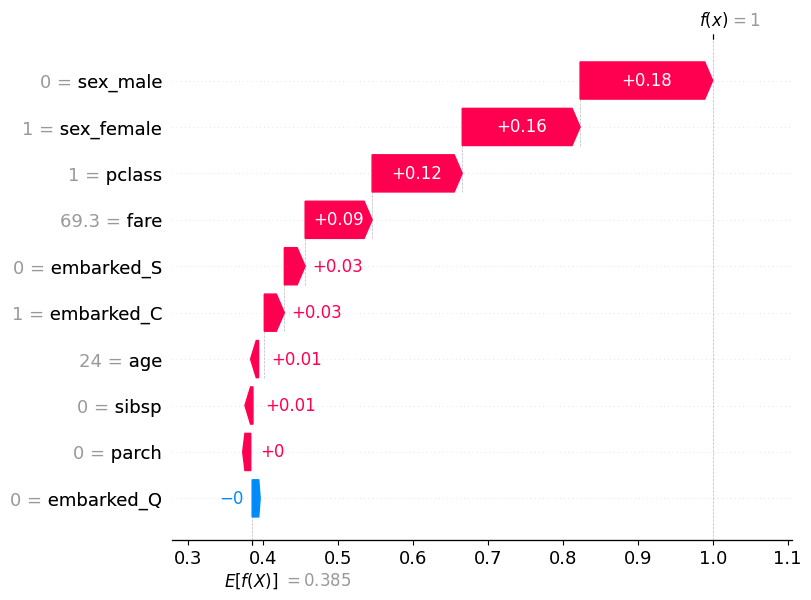

In [ ]:
shap.plots.waterfall(
    survived_shap[
        high_position
    ],
    max_display=10
)


### Compare the two cases

Ask:

- Which features receive the largest absolute attributions in each case?
- Are the same features important for both passengers?
- Do the attributions point in the same direction?
- How do the local explanations relate to the very different predicted probabilities?

This comparison illustrates why a global ranking cannot replace local explanations for individual predictions.


## 9. How variable are local explanations?

A feature can be globally important while still having very different attributions across individual observations.

To illustrate this, we inspect the distribution of SHAP values for the feature with the highest mean absolute attribution.


In [ ]:
top_feature = global_table.iloc[
    0
]["feature"]

top_feature_index = list(
    feature_names
).index(
    top_feature
)

top_feature_shap = survived_shap.values[
    :,
    top_feature_index
]

print(
    "Top global feature:",
    top_feature
)

print(
    "Minimum local SHAP value:",
    round(
        float(
            np.min(
                top_feature_shap
            )
        ),
        4
    )
)

print(
    "Maximum local SHAP value:",
    round(
        float(
            np.max(
                top_feature_shap
            )
        ),
        4
    )
)

print(
    "Mean absolute SHAP value:",
    round(
        float(
            np.mean(
                np.abs(
                    top_feature_shap
                )
            )
        ),
        4
    )
)


Top global feature: sex_male
Minimum local SHAP value: -0.1336
Maximum local SHAP value: 0.2516
Mean absolute SHAP value: 0.1184


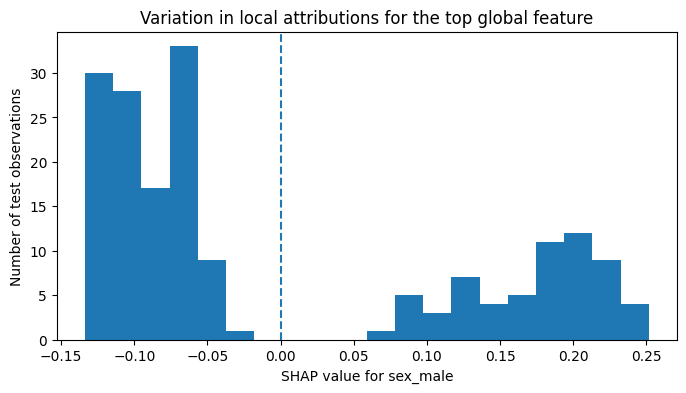

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    top_feature_shap,
    bins=20
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    f"SHAP value for {top_feature}"
)

plt.ylabel(
    "Number of test observations"
)

plt.title(
    "Variation in local attributions for the top global feature"
)

plt.show()


### Interpretation

A large global mean absolute SHAP value does not mean the feature contributes in the same way to every prediction.

The feature may:

- receive large positive attributions for some observations;
- receive negative attributions for others;
- receive small attributions for some cases.

Global and local explanations therefore provide complementary information.


## 10. Global vs. local explanations

| Question | Global explanation | Local explanation |
|---|---|---|
| Scope | Many observations / broader model behaviour | One observation or a small region |
| Example here | Mean absolute SHAP, beeswarm | SHAP waterfall |
| Typical question | Which features tend to receive large attributions? | Which features received important attributions for this prediction? |
| Can it describe one prediction precisely? | No | Yes |
| Can one example describe the whole model? | No | No |
| Causal interpretation by default? | No | No |

The distinction is primarily about **scope**.


## 11. Scientific cautions

### 1. Global summaries are aggregates

Mean absolute SHAP compresses many local explanations into one number per feature. Information about direction and individual variation is lost.

### 2. Local explanations are case-specific

One waterfall plot should not be generalised automatically to the entire model.

### 3. The explained dataset matters

A global SHAP summary depends on the observations over which the attributions are aggregated.

### 4. Feature representation matters

`sex_female` and `sex_male` are complementary representations of the same original binary variable. Their separate SHAP attributions belong to the encoded model representation.

### 5. SHAP attribution is not causal effect

Both global and local SHAP explanations describe the fitted model under the selected explainer setup. They do not establish real-world causal relationships.


## 12. Student task

Choose two test observations with different predicted survival probabilities.

For each observation:

1. display the raw passenger information;
2. report the predicted survival probability;
3. display the local SHAP waterfall plot;
4. identify the three largest absolute SHAP attributions;
5. state whether each attribution moves the class-1 output upward or downward.

Then compare the two explanations.

Answer:

- Which features are important in both cases?
- Which features differ between the two cases?
- Does the global ranking predict the exact local ranking for either passenger?
- Why should one local explanation not be used as a global explanation?
- Why should neither explanation be interpreted causally?


## 13. Questions for discussion

1. What makes an explanation global rather than local?
2. Why is mean absolute SHAP a global summary?
3. Why is a SHAP waterfall plot local?
4. What information is lost when local SHAP values are aggregated using absolute values?
5. Can a globally important feature have a small attribution for one observation?
6. Can the same feature have positive attribution for one observation and negative attribution for another?
7. Why does the explained set of observations matter for a global summary?
8. Why should a local explanation not be generalised automatically to the whole model?
9. Why do neither global nor local SHAP explanations establish causality?


## 14. Takeaway

Global and local explanations answer different questions about the same fitted model.

In this exercise:

- mean absolute SHAP values provide a global summary of attribution magnitude;
- the SHAP beeswarm shows how local attributions vary across many observations;
- waterfall plots explain individual predictions;
- two observations can have substantially different local explanations;
- a globally important feature does not have to dominate every individual prediction;
- local explanations should not be generalised automatically to the entire model.

Global and local explanations are therefore **complementary rather than interchangeable**.

Both should be interpreted as evidence about the fitted model and explainer setup, not as causal explanations of the real-world outcome.
